# Drogued drifter in synthetic sheared flow

We test the `DroguedDrifter` with a simple, analytically defined velocity
profile: uniform flow at the surface, weaker (or reversed) flow at drogue depth.
This lets us verify the drifter behaviour without any external data dependencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from drogued_drifters import DroguedDrifter

## Define a synthetic velocity profile

Surface current is 1 m/s eastward. The current at drogue depth decays
exponentially with an e-folding scale of 6 m. No northward component.

In [2]:
def sheared_uv(*, t, z_d, y_b, x_b):
    """Eastward surface current with exponential depth decay."""
    U_b = 1.0
    V_b = 0.0
    factor = np.exp(-abs(z_d) / 6.0)
    U_d = U_b * factor
    V_d = 0.0
    return U_b, V_b, U_d, V_d

## Set up two drifters

We compare a **complete drifter** (heavy drogue, strong drag) against a
**buoy-only** drifter (negligible drogue mass and drag). The buoy-only case
should simply follow the surface current.

In [3]:
drifter_complete = DroguedDrifter(
    m_b=1.3,
    m_d=1.3,
    k_b=20,
    k_d=200,
    get_uv=sheared_uv,
)

drifter_buoy = DroguedDrifter(
    m_b=1.3,
    m_d=0.01,
    k_b=20,
    k_d=0.01,
    get_uv=sheared_uv,
)

## Integrate trajectories

Starting from rest with the drogue at 135° from vertical (hanging sideways).

In [4]:
y0 = np.array([0.0, 0.0, 3 * np.pi / 4, 0.0, 0, 0, 0, 0])

T = 1800.0
dt = 5.0
t_eval = np.arange(0.0, T + dt, dt)

In [5]:
sol_complete = drifter_complete.get_full_solution((0, T), y0, t_eval=t_eval)
sol_buoy = drifter_buoy.get_full_solution((0, T), y0, t_eval=t_eval)

## Trajectories

The buoy-only drifter follows the surface current. The complete drifter is
slowed down by the drogue experiencing weaker flow at depth.

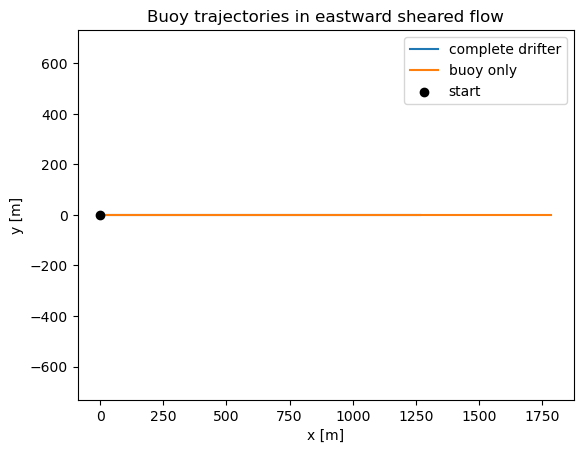

In [6]:
plt.plot(sol_complete.y[0], sol_complete.y[1], label="complete drifter")
plt.plot(sol_buoy.y[0], sol_buoy.y[1], label="buoy only")
plt.scatter([y0[0]], [y0[1]], color="k", zorder=5, label="start")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("Buoy trajectories in eastward sheared flow");

## Tether angle over time

The tether angle `theta` should settle from its initial value (135°) to a
steady state near 180° (drogue hanging below the buoy, slightly deflected
by shear).

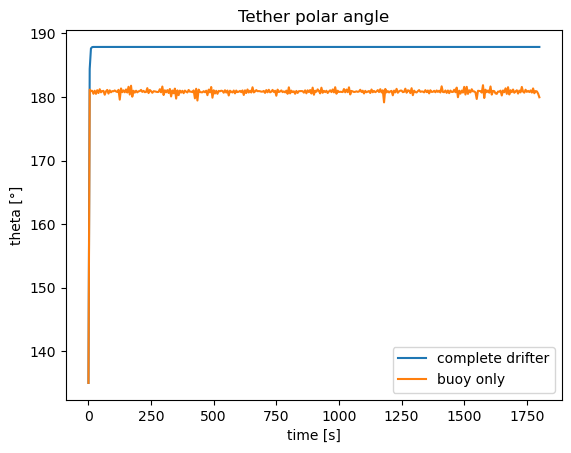

In [7]:
plt.plot(sol_complete.t, np.degrees(sol_complete.y[2]), label="complete drifter")
plt.plot(sol_buoy.t, np.degrees(sol_buoy.y[2]), label="buoy only")
plt.xlabel("time [s]")
plt.ylabel("theta [°]")
plt.legend()
plt.title("Tether polar angle");